## ASTER08 L2 LST product from Earth Data using `earthaccess`
Data download (until the heading: Inspection of the ASTER08 data) and exploration script for lake surface water temperatures of ice marginal lakes in Greenland from ASTEr08 L2 LST product. 
My credentials for NASA earth data:
- username: felician_gregor / email: 1.felician@web.de
- password: IML_inv_231!

Note: there is also something like a `harmony` API for NASA's earthexplorer data, which i now found out me be more convenient to use since it can already crop the dataset before downloading, preventing a couple of preprocessing steps and waste of time for downloading... (could possibly get implemented later)


In [30]:
# load libraries
import earthaccess
import pandas as pd
import numpy as np
import os
import rasterio
import geopandas as gpd
import xarray as xr
import rioxarray 
import pathlib
import matplotlib.pyplot as plt
from pathlib import Path

How to access data using `earthaccess`:
1. Check that all is fine with `earthaccess`
2. Login to NASA earthdata
3. simple search

In [31]:
# check all is in place for earth access
print(earthaccess.__version__) # seems to be alright

0.18.0


In [32]:
# login
auth = earthaccess.login(persist = True) # sucessful

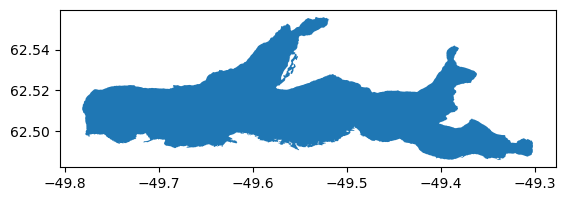

In [33]:
# read aoi with lake_id 6 within (Kangaarsuup Tasersua)
import geopandas as gpd

# lake shoreline
lake6_shore = gpd.read_file("../lake_polygons/lake_6_shoreline.geojson")
lake6_shore.plot()

bbox_shore = tuple(list(lake6_shore.total_bounds))

In [ ]:
# Do the same with the aoi_lake_6 polygon as area
search_results = earthaccess.search_data(
    short_name="AST_08", #FOR MARTHA: here you would need to specify the datasets name of landsat thermal product
    version="004",
    cloud_hosted = True, 
    bounding_box=bbox_shore, 
    temporal=("2000-01-01", "2026-08-20"),
    cloud_cover=(0, 100), # dont apply a cloud filter yet to maximise the number of scenes, screen then later.
    count=1000
)

# have a look
print(len(search_results)) # in total only 7 scenes in 2018!
search_results[4]



206


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\earthaccess\results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\earthaccess\results.py:375: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\earthaccess\formatters.py:40: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  granule_size = round(granule.size(), 2)


Collection: {'ShortName': 'AST_08', 'Version': '004'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -50.1316636334621, 'Latitude': 62.4652307492931}, {'Longitude': -49.7360266973875, 'Latitude': 61.9307906820485}, {'Longitude': -48.3805322580647, 'Latitude': 62.141346756944}, {'Longitude': -48.7544271120194, 'Latitude': 62.6794787084704}, {'Longitude': -50.1316636334621, 'Latitude': 62.4652307492931}]}}]}}}
Temporal coverage: {'SingleDateTime': '2001-08-04T00:48:16.980000Z'}
Size(MB): 0.7358970642089844
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_08.004/AST_08_00408042001004816_20250210203620/AST_08_00408042001004816_20250210203620_SKT.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_08.004/AST_08_00408042001004816_20250210203620/AST_08_00408042001004816_20250210203620_SKT_QA_DataPlane.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_08.004/AST_08_00408042001004816_20250210203620/AST_08_00408042001004816_20250210203620_SKT_QA_DataPlane2.tif']

In [35]:
# this is apparently the function to download, and then use xarray to hold the data in python

# make a dir first
download_dir = Path("data/")
download_dir.mkdir(parents=True, exist_ok=True)

fileset = earthaccess.download(
    search_results,
    local_path=str(download_dir)
)

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\earthaccess\store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/618 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/618 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/618 [00:00<?, ?it/s]

## Inspection of the ASTER08 data
I have now downloaded the data to a local folder and can read the data into the memory to inspect the data. SKT files are the ones with the data, while QA denotes QualityAssessment auxiliry files. 
I will use only the year 2018 for the data inspection, the year is chosen randomly. 
First, i get the aquisition date from the file name, then read in only the few scenes from 2018 and inspect them all in a seperate plot. 
Then, I clip the scenes by the lake boundary for closer inspection. 
Finally, i try to do the cloud filtering, however, it seems like this is not working properly. There is only a cloud summery for the whole scenes, which would waste lots of scnes where the lake itself is not covered by clouds (see here for information on the `QA` data and its encoding, page 31: https://asterweb.jpl.nasa.gov/content/03_data/04_Documents/ASTER%20QA%20Plan%20v2.0.pdf). I therefore have another script where i do a manual cloud screening. 

In [36]:
folder = pathlib.Path(r"C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\ASTER08_LSWT\data")
files = sorted(folder.glob("*_SKT.tif"))
files_QA = sorted(folder.glob("*_QA_DataPlane.tif"))
files_QA2 = sorted(folder.glob("*_QA_DataPlane.tif"))
# QA_DataPlane
print(files_QA[0])

C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\ASTER08_LSWT\data\AST_08_00403082008145510_20250620191042_SKT_QA_DataPlane.tif


### get a datetime object from the file name


In [37]:
from pathlib import Path
from datetime import datetime
import re

# function to get a datetime oject 
def extract_aster_acquisition_datetime(filename):
    name = Path(filename).name
    pattern = r"^AST_\w+_(\d{3})(\d{14})_\d{14}"
    match = re.match(pattern, name)

    if not match:
        raise ValueError(f"Not a recognized ASTER filename: {name}")

    acquisition = match.group(2)

    # Acquisition timestamp is MMDDYYYYHHMMSS
    return datetime.strptime(acquisition, "%m%d%Y%H%M%S")

#apply
datetime_ASTER08 = []
for file in files:
    datetime_ASTER08.append(extract_aster_acquisition_datetime(filename = file))

print(f"number of ASTER img:{len(datetime_ASTER08)}")

number of ASTER img:206


Here I first check out the images for 2018 in order to see how many scenes there are etc. 

In [38]:
### and get the number of images from 2018 and the file names
# Dictionaries or lists to store the 2018 filtered data
images_2018 = {}

for file in files:
    dt = extract_aster_acquisition_datetime(filename=file)
    
    # Filter for the year 2018
    if dt.year == 2018:
        # Store filename as key and formatted string date as value
        images_2018[Path(file).name] = dt.strftime("%Y-%m-%d %H:%M:%S")

print(images_2018)


{'AST_08_00404212018145615_20250826195902_SKT.tif': '2018-04-21 14:56:15', 'AST_08_00404212018145623_20250826200305_SKT.tif': '2018-04-21 14:56:23', 'AST_08_00406082018145646_20250827161026_SKT.tif': '2018-06-08 14:56:46', 'AST_08_00406082018145654_20250827161209_SKT.tif': '2018-06-08 14:56:54', 'AST_08_00409122018145637_20250829145150_SKT.tif': '2018-09-12 14:56:37', 'AST_08_00409122018145646_20250829145717_SKT.tif': '2018-09-12 14:56:46', 'AST_08_00409192018150244_20250829174949_SKT.tif': '2018-09-19 15:02:44'}


### Plot the 2018 images to get a feeling for the data

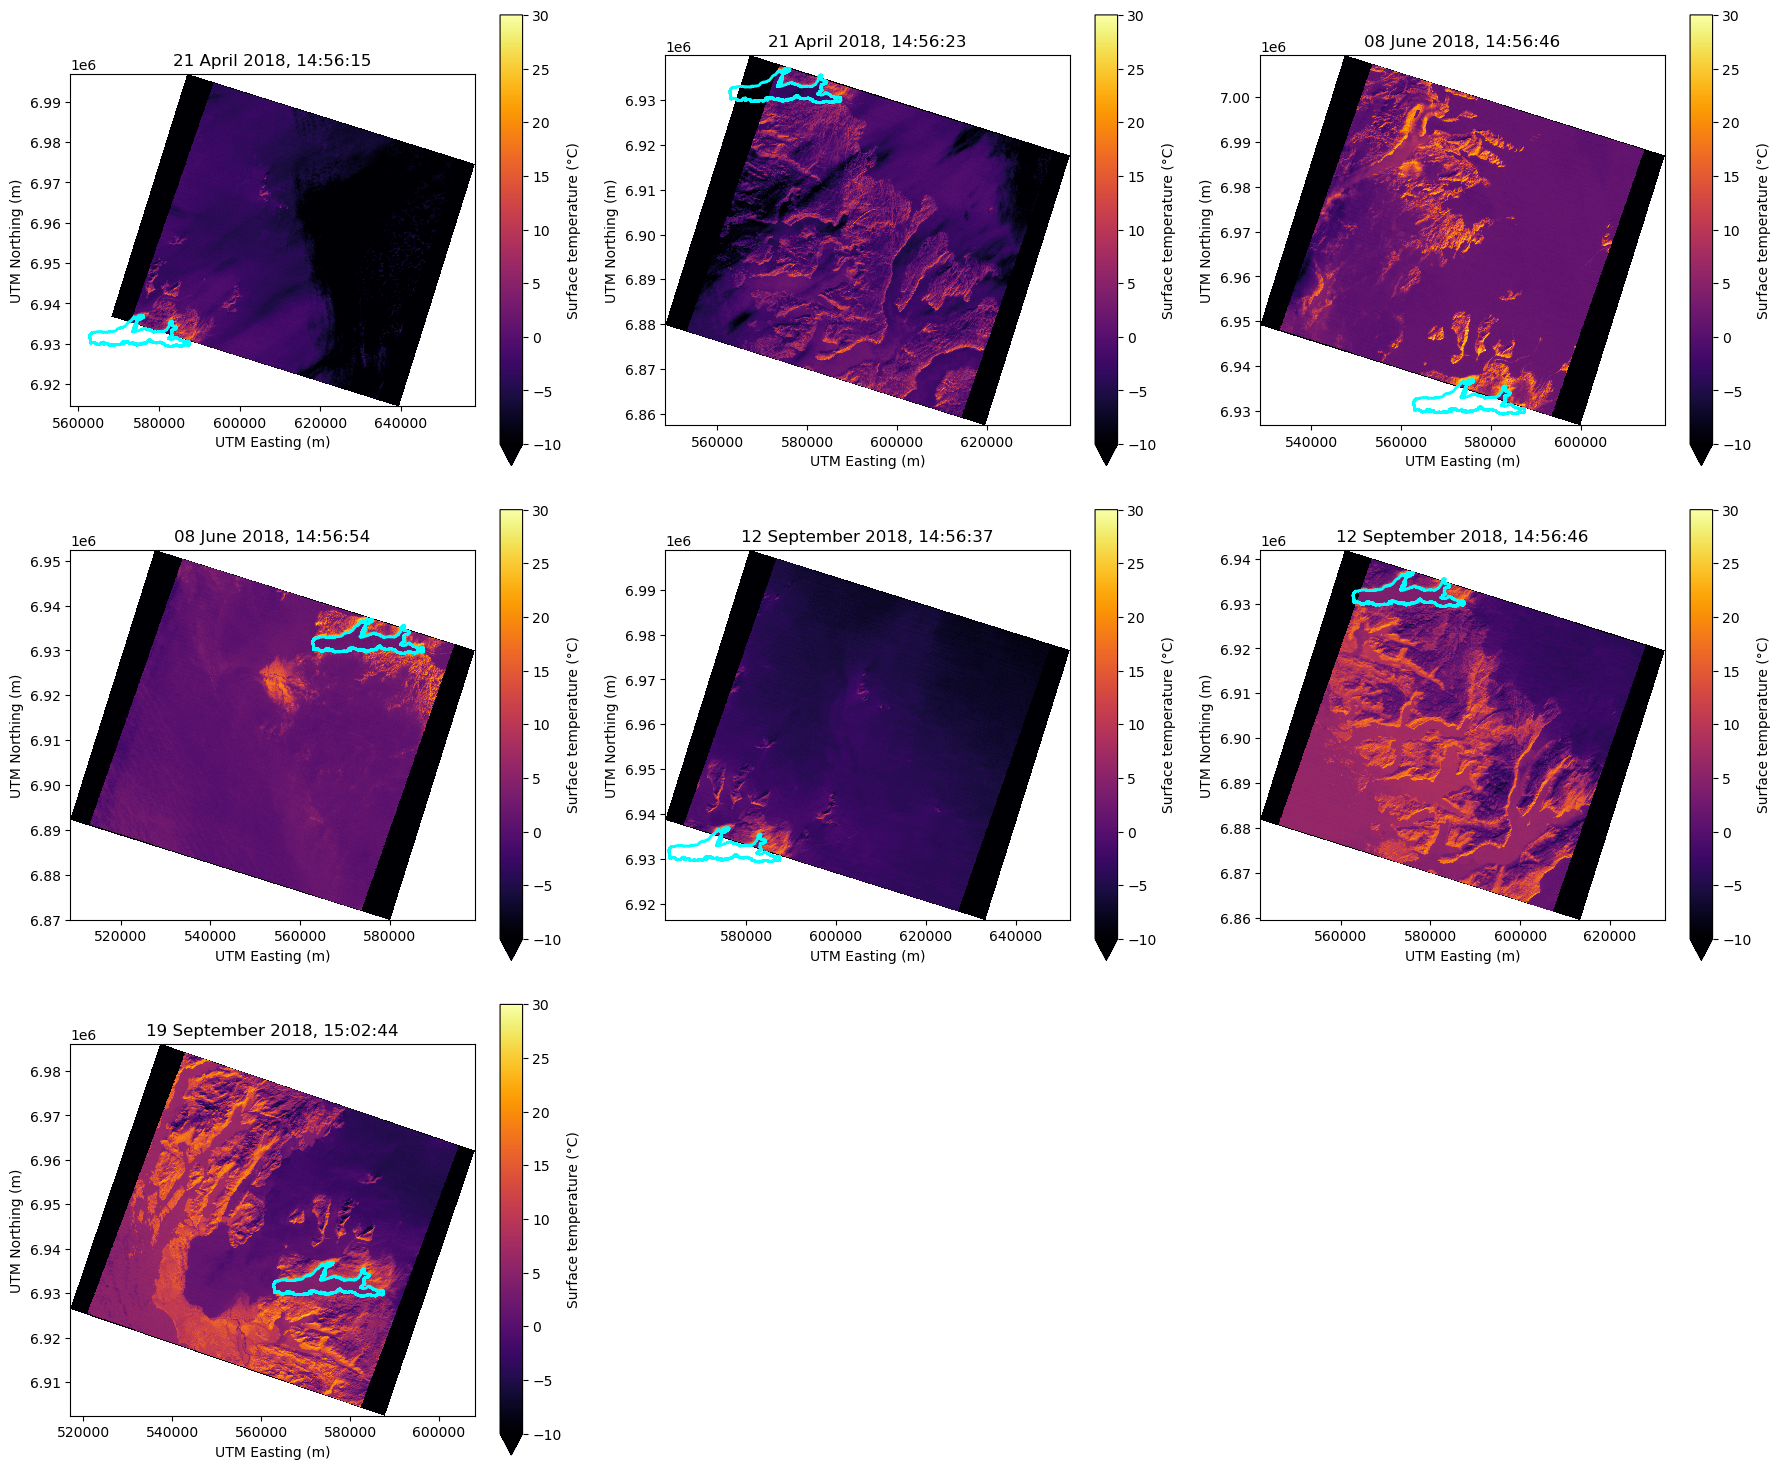

In [39]:
# import the shoreline of lake_6
lake6_shore = gpd.read_file("../lake_polygons/lake_6_shoreline.geojson")

# reproject the lake boundaries
lake6_shore_32622 = lake6_shore.to_crs(epsg = 32622)

import math
import matplotlib.pyplot as plt
import rioxarray

ncols = 3
vmin = -10
vmax = 30

# 1. Filter files for 2018 FIRST
files_subset = files
valid_files = []
for file in files_subset:
    if extract_aster_acquisition_datetime(file).year == 2018:
        valid_files.append(file)

# 2. Calculate grid based ONLY on valid files
n = len(valid_files)
if n == 0:
    print("No files found for the year 2018.")
else:
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 5 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    # 3. Plot sequentially without skipping slots
    for i, file in enumerate(valid_files):
        img = rioxarray.open_rasterio(file) # open raster 
        da = (img * 0.1) - 273.15 # scale to celsius
        ax = axes[i]

        # Get acquisition datetime
        acquisition_dt = extract_aster_acquisition_datetime(file)
        title = acquisition_dt.strftime("%d %B %Y, %H:%M:%S")

        # temperature raster
        da.plot(
            ax=ax,
            x="xc",
            y="yc",
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            add_colorbar=True,
            cbar_kwargs={"label": "Surface temperature (°C)"}
        )
        
        # lake shoreline
        lake6_shore_32622.plot(
            ax=ax,
            facecolor="none",
            edgecolor="cyan",
            linewidth=2
        )
        
        # title and labels
        ax.set_title(title)
        ax.set_xlabel("UTM Easting (m)")
        ax.set_ylabel("UTM Northing (m)")

    # 4. Hide any remaining empty subplots at the end of the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


### This is now a more detailed inspection of only those dates that seem to be cloud free. 

In [40]:
# read in only those files that seem cloud free (above the lake)
files_2018 = ['data/AST_08_00404212018145623_20250826200305_SKT.tif', 'data/AST_08_00409122018145646_20250829145717_SKT.tif', 'data/AST_08_00409192018150244_20250829174949_SKT.tif']

<Axes: title={'center': 'band = 1, spatial_ref = 0'}, xlabel='xc', ylabel='yc'>

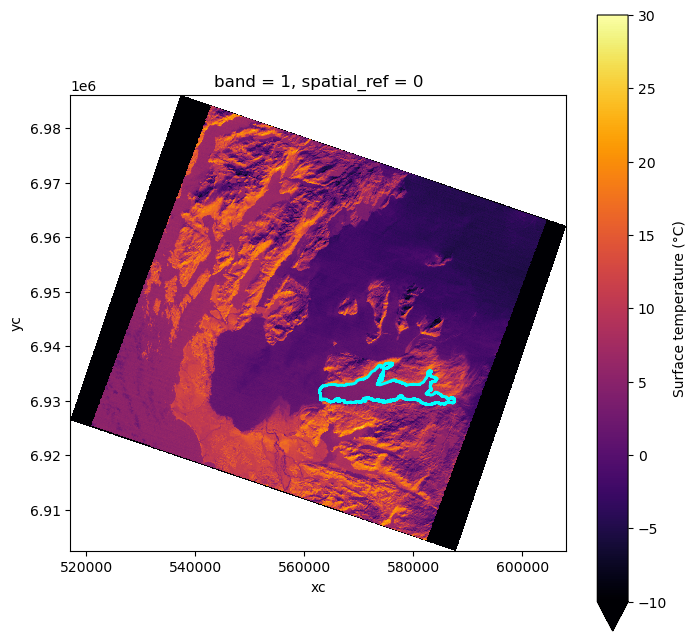

In [ ]:
#load here just one, change the index to change the imagery

import rasterio
from rasterio.plot import show

Sept_19 = rioxarray.open_rasterio(files_2018[2]) # open raster 
Sept_19 = (Sept_19 * 0.1) - 273.15 # scale to celsius

fig, ax = plt.subplots(figsize = (8, 8))
# Pass the opened file to the show function
Sept_19.plot(ax=ax,
    x="xc",y="yc",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
    cbar_kwargs={"label": "Surface temperature (°C)"})
        
        # lake shoreline
lake6_shore_32622.plot(
            ax=ax,
            facecolor="none",
            edgecolor="cyan",
            linewidth=2)



In [42]:
# clip by lake boundaries
Sept_19_clipped = Sept_19.rio.clip(lake6_shore_32622.geometry, lake6_shore_32622.crs)
Sept_19_clipped.coords

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


Coordinates:
  * band         (band) int64 8B 1
    xc           (y, x) float64 273kB 5.661e+05 5.661e+05 ... 5.85e+05 5.85e+05
    yc           (y, x) float64 273kB 6.941e+06 6.941e+06 ... 6.923e+06
    spatial_ref  int64 8B 0

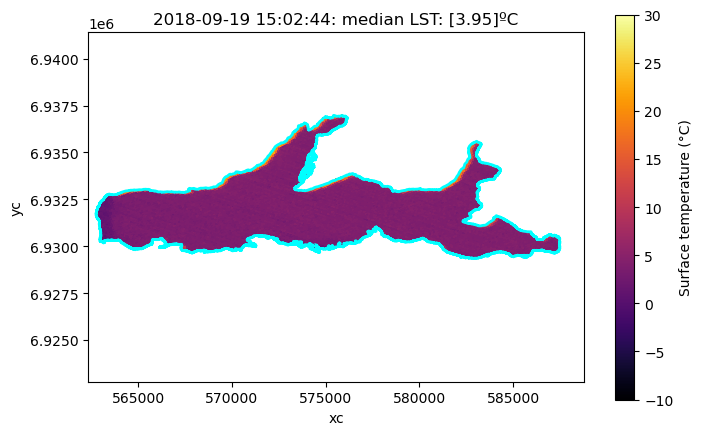

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


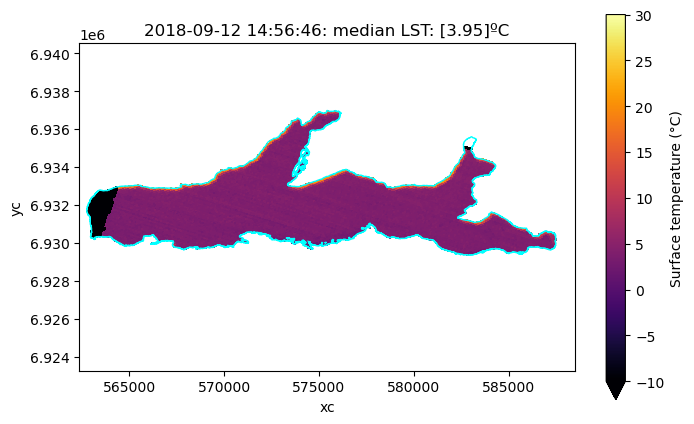

In [43]:
# plot quickly

# get the temp for 19 Sept
Sept_19_temp = Sept_19_clipped.median(dim = ("x", "y"))

fig, ax = plt.subplots(figsize = (8, 5))
# Pass the opened file to the show function
Sept_19_clipped.plot(ax=ax,
    x="xc",y="yc",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
    cbar_kwargs={"label": "Surface temperature (°C)"})
        
        # lake shoreline
lake6_shore_32622.plot(
            ax=ax,
            facecolor="none",
            edgecolor="cyan",
            linewidth=2)
plt.title(f'{extract_aster_acquisition_datetime(files_2018[2])}: median LST: {Sept_19_temp.values}ºC')
plt.show()


### now for September 12 2018
Sept_12 = rioxarray.open_rasterio(files_2018[1]) # open raster 
Sept_12 = (Sept_12 * 0.1) - 273.15 # scale to celsius
Sept_12_clipped = Sept_12.rio.clip(lake6_shore_32622.geometry, lake6_shore_32622.crs)
Sept_12_temp = Sept_12_clipped.median(dim = ("x", "y"))


fig, ax = plt.subplots(figsize = (8, 5))
# Pass the opened file to the show function
Sept_12_clipped.plot(ax=ax,
    x="xc",y="yc",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
    cbar_kwargs={"label": "Surface temperature (°C)"})
        
        # lake shoreline
lake6_shore_32622.plot(
            ax=ax,
            facecolor="none",
            edgecolor="cyan",
            linewidth=1)
plt.title(f'{extract_aster_acquisition_datetime(files_2018[1])}: median LST: {Sept_12_temp.values}ºC')
plt.show()




In [44]:
# define a function to plot lake shore and ASTER data of cloud free scenes for 2018

import matplotlib.pyplot as plt
import rioxarray


def plot_lake_temperature(
    file_path, lake, cmap="inferno", edgecolor="cyan", linewidth=1):
    
    # open raster 
    raster = rioxarray.open_rasterio(file_path)
    raster_celsius = (raster * 0.1) - 273.15

    #clip by lake boundary
    clipped_raster = raster_celsius.rio.clip(lake.geometry, lake.crs)

    #calc median temp
    median_temp = clipped_raster.median(dim=("x", "y"))

    #plot
    fig, ax = plt.subplots(figsize=(8, 5))

    clipped_raster.plot(
        ax=ax,
        x="xc",
        y="yc",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": "Surface temperature (°C)"},)

    # 5. Overlay the lake shoreline
    lake.plot(
        ax=ax, facecolor="none", edgecolor=edgecolor, linewidth=linewidth)

    # get time of aquisicion and ut into title together with median temp
    acq_time = extract_aster_acquisition_datetime(file_path)
    plt.title(f"{acq_time}: median LST: {median_temp.values}ºC")

    plt.show()

    #return clipped_raster  #return raster


data/AST_08_00404212018145623_20250826200305_SKT.tif


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


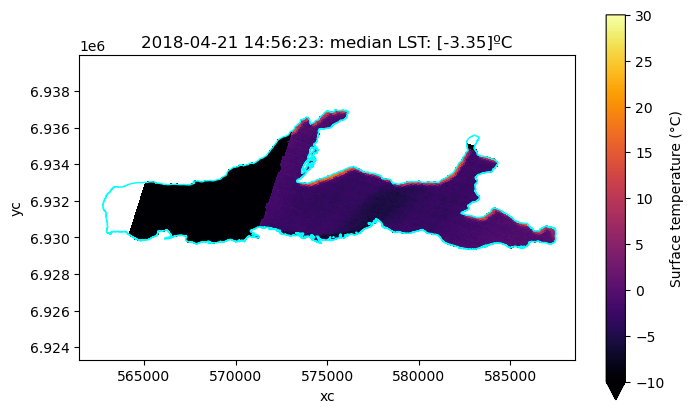

data/AST_08_00409122018145646_20250829145717_SKT.tif


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


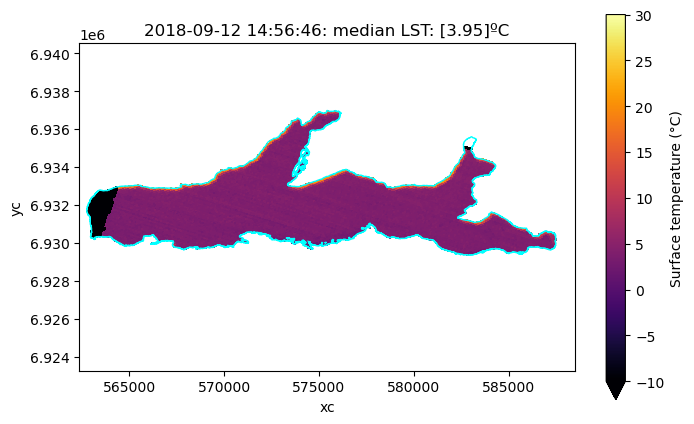

data/AST_08_00409192018150244_20250829174949_SKT.tif


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


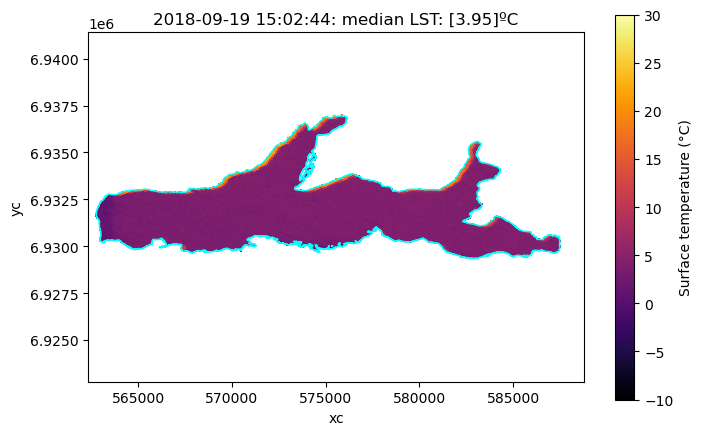

In [45]:
# apply function to file_2018

for file in files_2018:
    print(file)
    plot_lake_temperature(
        file_path = file, 
        lake = lake6_shore_32622)

### Cloud filtering - faled using QA auxiliry data
This is an attempt to use the QA data for cloud filtering. Information on the QA planes can be found here. In short, best data is indicated by `0`, and from bit 5 to 8 (2**5 - 2**8) cloud levels are encoded. However, this does not seem to work properly. Parts of the scenes clearly affected by clouds are not in the bad quality/cloud mask but instead marke as `0` (best quality), as it appears? 

Information on the encoding can be found here:
https://asterweb.jpl.nasa.gov/content/03_data/04_Documents/ASTER%20QA%20Plan%20v2.0.pdf

Therefore, I use a manual approch to filter out scnes where the lake is covered by clouds, see script called `manually_class_cloud_scenes.ipynb`.

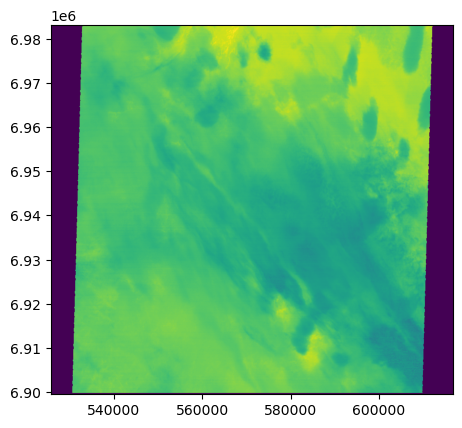

Unique QA values: [  0  48 144 176]


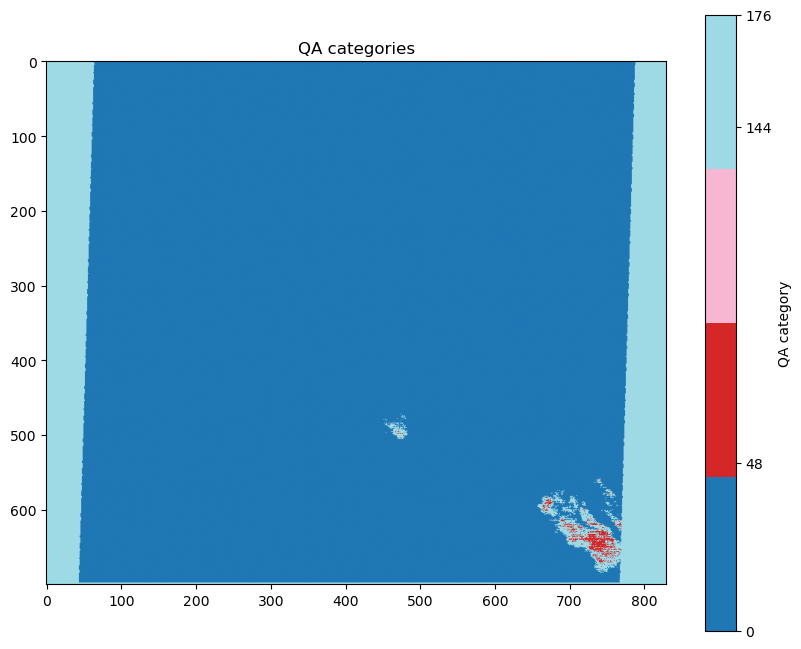

In [46]:

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from matplotlib.colors import ListedColormap

with rasterio.open(files[11]) as img:
    show(img)

with rasterio.open(files_QA2[11]) as src:
    qa = src.read(1)
    nodata = src.nodata

# Get unique values, excluding nodata
values = np.unique(qa)
if nodata is not None:
    values = values[values != nodata]

print("Unique QA values:", values)

# Create a categorical colormap
cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, len(values))))

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(qa, cmap=cmap)
plt.colorbar(
    ticks=values,
    label="QA category"
)
plt.title("QA categories")
plt.show()